In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv("Cleaned_Dataset.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   121 non-null    int64  
 1   day          121 non-null    int64  
 2   month        121 non-null    int64  
 3   year         121 non-null    int64  
 4   Temperature  121 non-null    int64  
 5   RH           121 non-null    int64  
 6   Ws           121 non-null    int64  
 7   Rain         121 non-null    float64
 8   FFMC         121 non-null    float64
 9   DMC          121 non-null    float64
 10  DC           121 non-null    float64
 11  ISI          121 non-null    float64
 12  BUI          121 non-null    float64
 13  FWI          121 non-null    float64
 14  Classes      121 non-null    object 
dtypes: float64(7), int64(7), object(1)
memory usage: 14.3+ KB


In [4]:
df.describe()

,Unnamed: 0,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI
count,121.000000,121.000000,121.000000,121.0,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000
mean,60.644628,15.768595,7.504132,2012.0,33.132231,56.057851,14.983471,0.682645,81.038017,17.066116,45.670248,5.838017,17.965289,8.504959
std,35.473196,8.878589,1.118958,0.0,3.674103,15.686139,2.689434,1.492296,12.274182,13.043604,43.013408,4.815068,13.919595,8.169444
min,0.000000,1.000000,6.000000,2012.0,24.000000,21.000000,6.000000,0.000000,37.900000,0.900000,7.300000,0.100000,1.400000,0.000000
25%,30.000000,8.000000,7.000000,2012.0,30.000000,44.000000,14.000000,0.000000,77.500000,7.200000,14.700000,1.800000,7.300000,0.900000
50%,61.000000,16.000000,8.000000,2012.0,34.000000,56.000000,15.000000,0.000000,84.700000,13.300000,32.100000,4.500000,14.100000,6.000000
75%,91.000000,23.000000,8.000000,2012.0,36.000000,67.000000,16.000000,0.500000,89.300000,23.000000,57.100000,8.400000,23.900000,13.700000
max,121.000000,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,8.700000,96.000000,65.900000,177.300000,19.000000,68.000000,31.100000


In [5]:
df = df.drop("Unnamed: 0", axis=1)

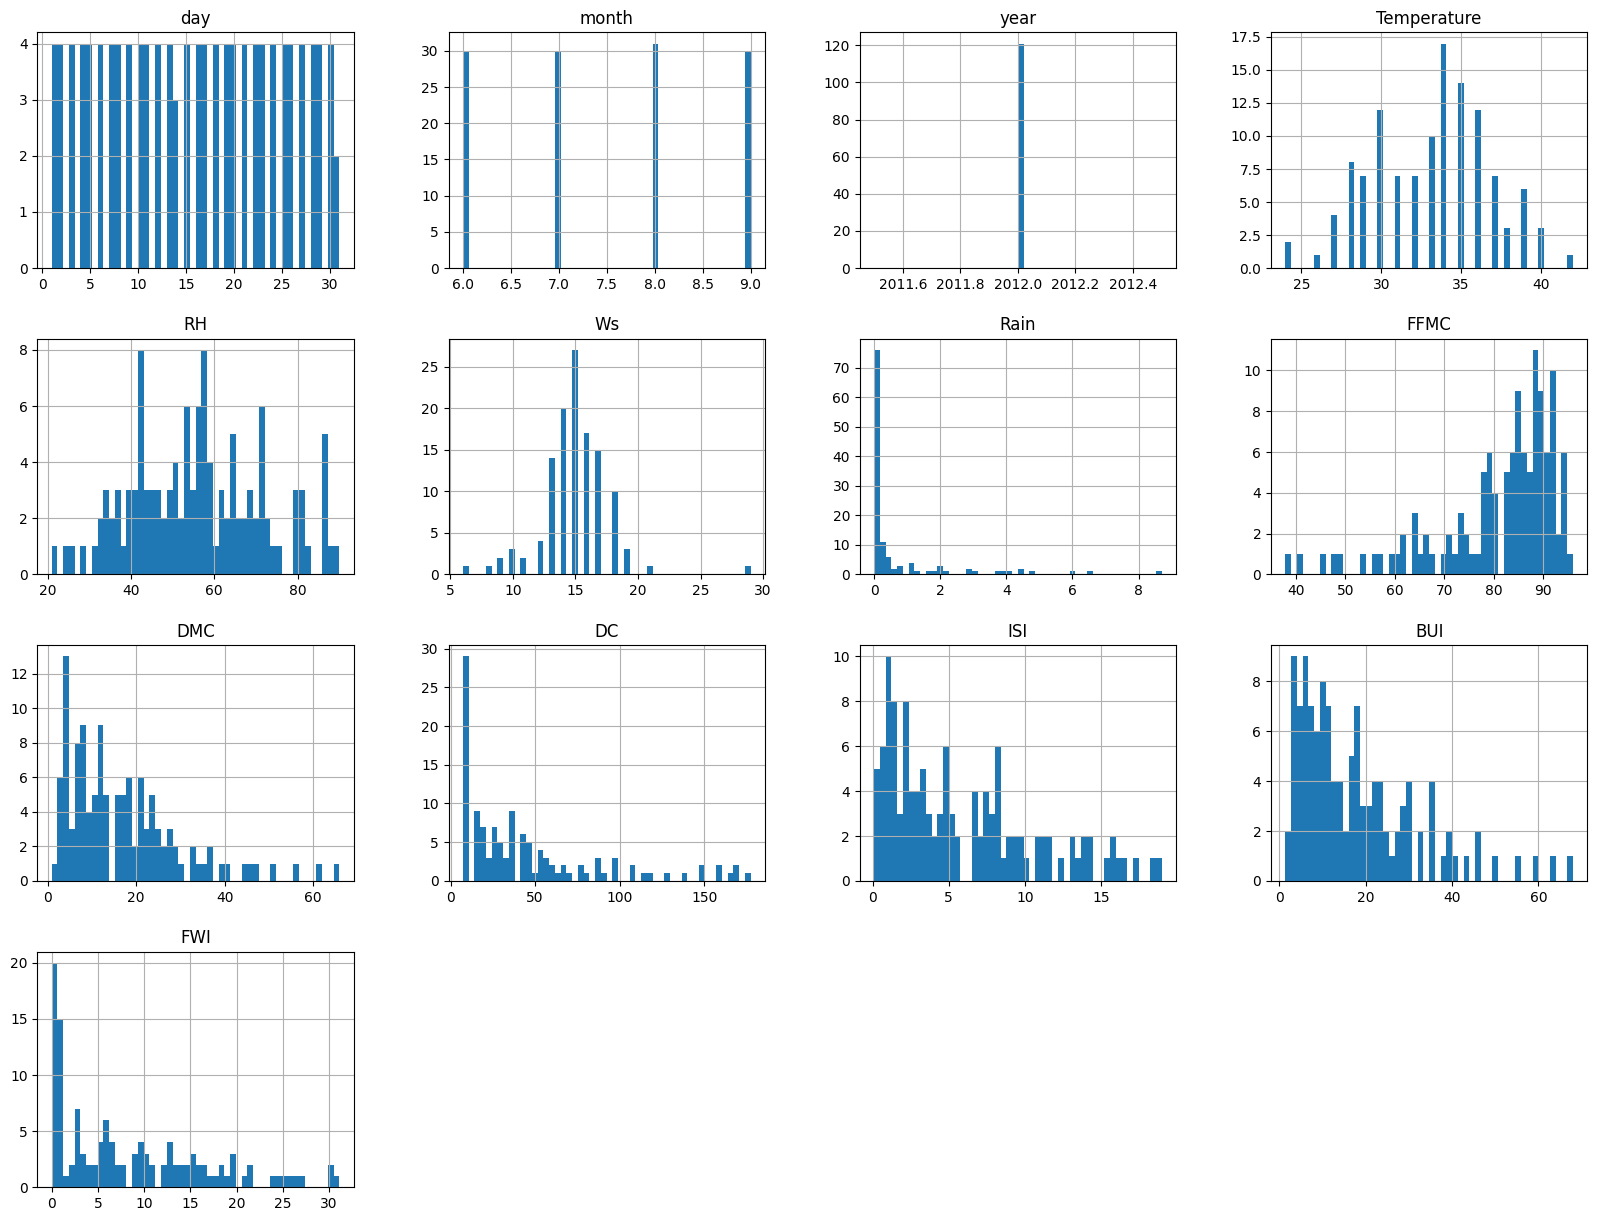

In [10]:
df.hist(bins=50,figsize=(20,15))
plt.show()

### The Constants & Categoricals: The year is entirely constant (it only contains 2012), meaning it provides no predictive power and should be dropped later. The month data is perfectly bucketed between June (6) and September (9)

In [11]:
## Percentage for Pie Chart
percentage=df['Classes'].value_counts(normalize=True)*100

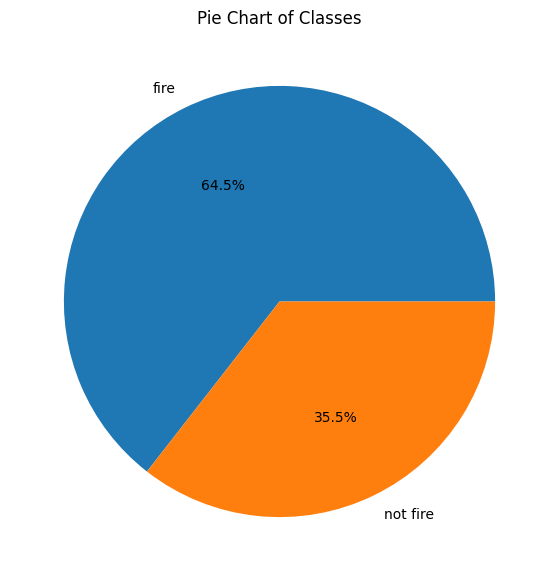

In [12]:
# plotting piechart
classlabels=["fire","not fire"]
plt.figure(figsize=(12,7))
plt.pie(percentage,labels=classlabels,autopct='%1.1f%%')
plt.title("Pie Chart of Classes")
plt.show()

### This dataset is slightly imbalanced but entirely workable. Fires occurred on 64.5% of the recorded days, while 35.5% of the days had no fires. Because the split isn't extremely drastic (like 99% vs 1%), standard machine learning evaluation metrics like Accuracy will still be fairly reliable, though Precision and Recall will be important when evaluating the final model.

<Axes: >

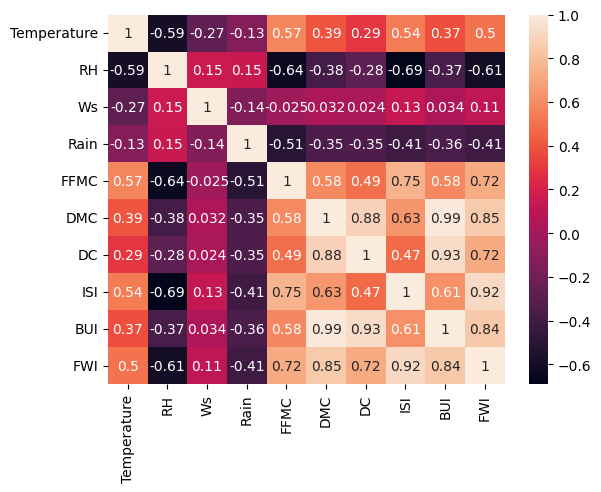

In [15]:
df_copy=df.drop(["day","month","year","Classes"],axis=1)
sns.heatmap(df_copy.corr(),annot=True)

### Temperature has a solid positive correlation with the fire indices (as it gets hotter, fire risk goes up). Conversely, RH (Relative Humidity) has a strong negative correlation with indices like FFMC (-0.64) and ISI (-0.69). When humidity drops, fire danger spikes.

<Axes: xlabel='month', ylabel='count'>

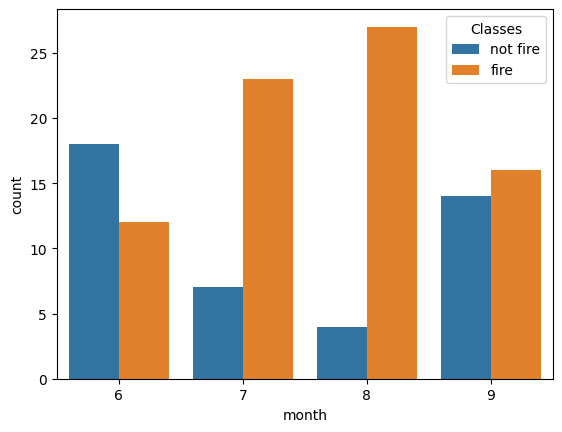

In [26]:
sns.countplot(x='month',hue='Classes',data=df)

### The relationship here is the inverse of temperature. The median humidity on fire days drops significantly to around 48%, compared to a much more humid 64% on non-fire days.

<Axes: ylabel='Temperature'>

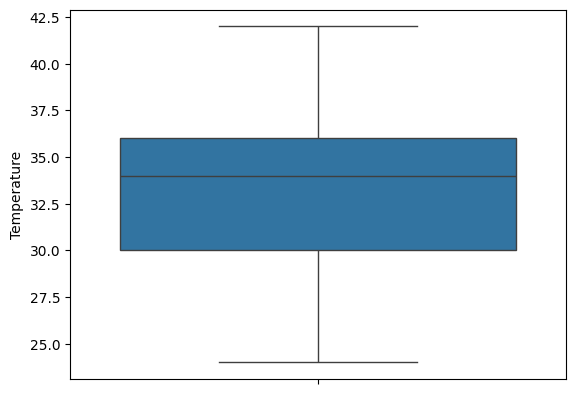

In [17]:
sns.boxplot(df["Temperature"])

<Axes: ylabel='Ws'>

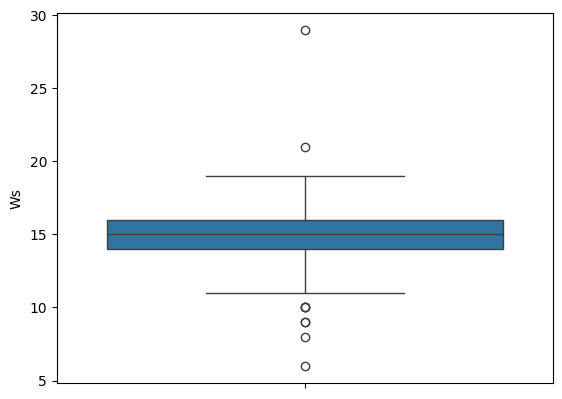

In [18]:
sns.boxplot(df["Ws"])

<Axes: ylabel='Rain'>

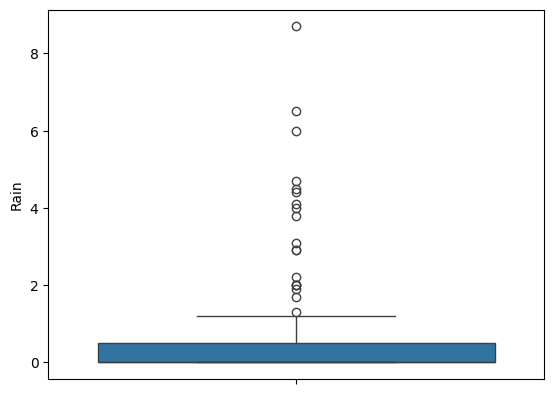

In [19]:
sns.boxplot(df["Rain"])

Text(0.5, 1.0, 'Temperature Distribution by Class')

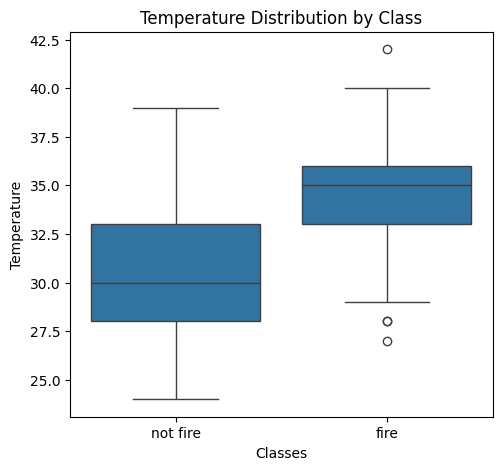

In [23]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Classes', y='Temperature')
plt.title('Temperature Distribution by Class')

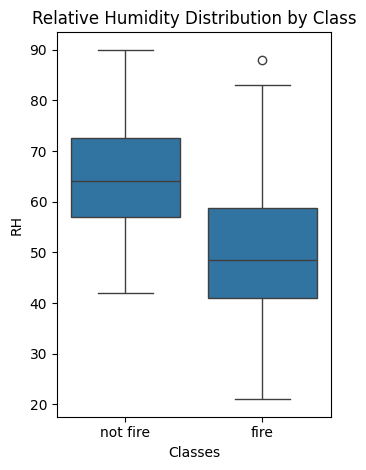

In [24]:
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Classes', y='RH')
plt.title('Relative Humidity Distribution by Class')
plt.tight_layout()
plt.show()

### The boxplots show a distinct separation in the median temperatures. Days with fires have a median temperature hovering around 35°C, while non-fire days have a median closer to 30°C.

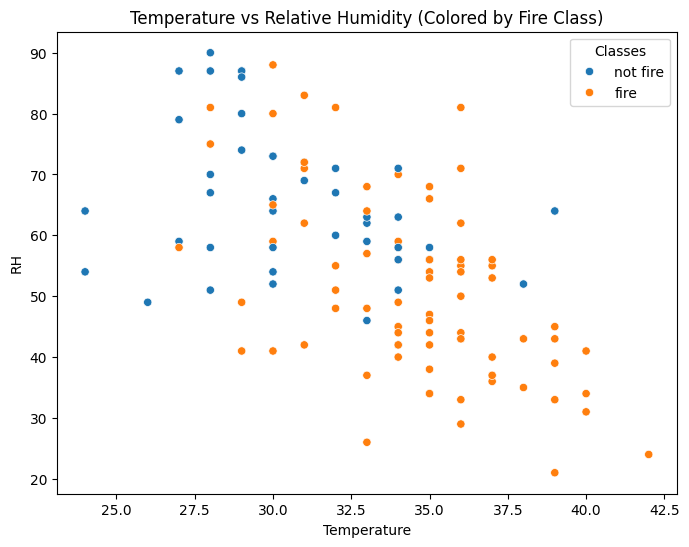

In [25]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Temperature', y='RH', hue='Classes')

plt.title('Temperature vs Relative Humidity (Colored by Fire Class)')
plt.show()

### By plotting Temperature against RH and separating the classes by color, a clear cluster emerges. The bottom-right quadrant of the graph—representing high temperatures (>32°C) and low humidity (<50%)—is densely populated almost exclusively by orange "fire" data points.